# Exercise 3. Aperiodic Boundaries

3.1 Aperiodic Boundaries Introduce Edge Artifacts in the Grid Pattern

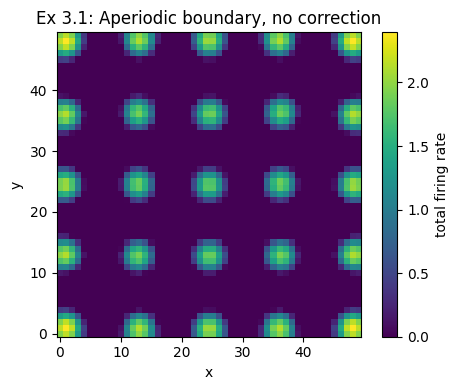

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from helper import Grid2DParams, AperiodicGridIntegrator

params3 = Grid2DParams(m=50)

velocity = np.zeros((400, 2))

net_aperiodic = AperiodicGridIntegrator(
    params=params3,
    boundary_mode="none",
)

out_31 = net_aperiodic.simulate(
    velocity=velocity,
    seed=0,
    store_history=True,
)

plt.figure(figsize=(5, 4))
plt.imshow(out_31["final_rate_total"], origin="lower", cmap="viridis")
plt.colorbar(label="total firing rate")
plt.title("Ex 3.1: Aperiodic boundary, no correction")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

With aperiodic boundaries, the network no longer forms a clean grid pattern over the whole sheet. The activity is strongly distorted by the edges, with high firing-rate bumps appearing near the boundaries and corners. This happens because neurons near the edge lose recurrent inputs from outside the sheet, so they do not experience the same effective connectivity as neurons in the center. Thus, removing the periodic wrapping breaks translational symmetry and introduces clear boundary artifacts.

3.2  2D radial masking envelope

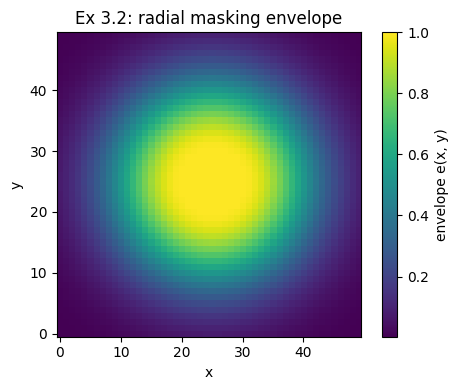

In [2]:
from helper import radial_envelope

env = radial_envelope(m=50, gamma=0.08, fratio=0.2)

plt.figure(figsize=(5, 4))
plt.imshow(env, origin="lower", cmap="viridis")
plt.colorbar(label="envelope e(x, y)")
plt.title("Ex 3.2: radial masking envelope")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

3.3 Boundary Firing-Rate Attenuation Partially Restores Central Bumps

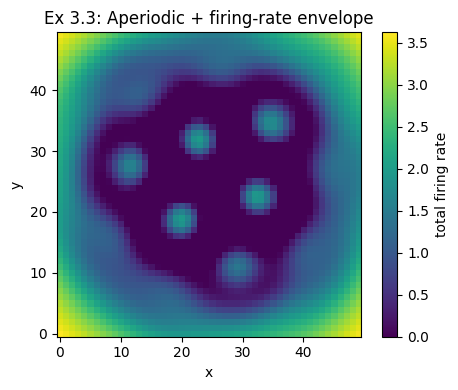

In [3]:
net_rate_env = AperiodicGridIntegrator(
    params=params3,
    boundary_mode="rate_envelope",
)

out_33 = net_rate_env.simulate(
    velocity=velocity,
    seed=0,
    store_history=True,
)

plt.figure(figsize=(5, 4))
plt.imshow(out_33["final_rate_total"], origin="lower", cmap="viridis")
plt.colorbar(label="total firing rate")
plt.title("Ex 3.3: Aperiodic + firing-rate envelope")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

For this simulation, I scaled the firing rates of the four populations by the radial envelope $e(\vec{x})$ before computing the recurrent convolution:

$$
r_N, r_S, r_E, r_W \rightarrow e(\vec{x}) r_N, e(\vec{x}) r_S, e(\vec{x}) r_E, e(\vec{x}) r_W.
$$

This implements the proposed attenuation of the outgoing weights of neurons near the boundary, because boundary neurons contribute less strongly to the recurrent input received by other neurons.

In the final activity pattern, several localized bumps are visible in the central region, so the network still maintains some grid-like structure. However, the correction is not perfect: in my simulation, strong activity remains near the edges and corners, and the pattern is less regular than in the periodic-boundary case. This suggests that attenuating outgoing recurrent influence reduces some boundary effects, but it does not fully remove the edge artifacts. One likely reason is that boundary neurons still receive the same external input, so their own activity can remain high even though their outgoing recurrent contribution is weakened.

3.4 Input Envelope Suppresses Boundary Artifacts More Effectively

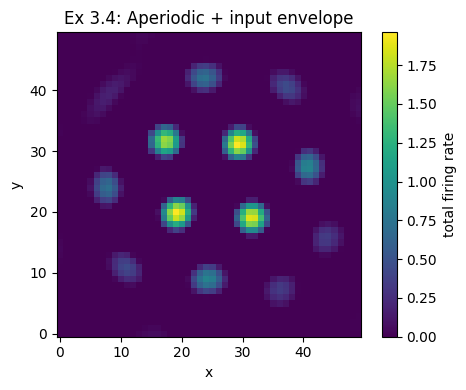

In [4]:
net_input_env = AperiodicGridIntegrator(
    params=params3,
    boundary_mode="input_envelope",
)

out_34 = net_input_env.simulate(
    velocity=velocity,
    seed=0,
    store_history=True,
)

plt.figure(figsize=(5, 4))
plt.imshow(out_34["final_rate_total"], origin="lower", cmap="viridis")
plt.colorbar(label="total firing rate")
plt.title("Ex 3.4: Aperiodic + input envelope")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

For this simulation, I used the same aperiodic boundary condition as before, but instead of scaling the firing rates before convolution, I multiplied the external inputs by the radial envelope $e(\vec{x})$:

$$
B_N, B_S, B_E, B_W \rightarrow e(\vec{x})B_N, e(\vec{x})B_S, e(\vec{x})B_E, e(\vec{x})B_W.
$$

This makes the input position-dependent: neurons near the center receive the full input, while neurons near the boundary receive weaker input.

Compared with Ex. 3.3, the final activity pattern looks cleaner. The high-activity artifacts near the edges and corners are strongly reduced, and the activity is mainly concentrated in the central region. A grid-like bump pattern is still visible, although it is not perfectly regular because the aperiodic boundary and the spatial envelope break translational symmetry.

In my simulation, input attenuation works better than outgoing-weight attenuation. This suggests that directly reducing the drive to boundary neurons is more effective at suppressing boundary artifacts than only weakening their outgoing recurrent influence.

3.5 Comparing Boundary Corrections: Outgoing Weight Attenuation vs Input Attenuation

The two approaches differ in what is being attenuated near the boundary.

In Ex. 3.3, the envelope is applied to the firing rates before convolution:

$$
r_N, r_S, r_E, r_W \rightarrow e(\vec{x})r_N, e(\vec{x})r_S, e(\vec{x})r_E, e(\vec{x})r_S.
$$

This means that neurons near the boundary have weaker outgoing recurrent influence on the rest of the network. In other words, boundary neurons can still receive normal external input and become active, but their contribution to the recurrent input of other neurons is reduced.

In Ex. 3.4, the envelope is applied to the external inputs:

$$
B_N, B_S, B_E, B_W \rightarrow e(\vec{x})B_N, e(\vec{x})B_S, e(\vec{x})B_E, e(\vec{x})B_W.
$$

This means that neurons near the boundary receive weaker external drive in the first place. Therefore, boundary neurons are less strongly activated, which directly suppresses edge and corner artifacts.

In my simulations, the input-envelope approach in Ex. 3.4 works better. It produces a cleaner central grid-like pattern and reduces the strong boundary activity more effectively than the firing-rate envelope in Ex. 3.3. The firing-rate envelope still leaves noticeable edge artifacts, probably because boundary neurons continue to receive the same tonic input even though their outgoing recurrent effect is weakened.

This distinction has biological implications. The method in Ex. 3.3 corresponds more to a change in recurrent connectivity or synaptic output near the edge of the neural sheet. The method in Ex. 3.4 corresponds more to a spatial modulation of input drive, excitability, or gain. If a biological grid-cell circuit avoids boundary artifacts, the model suggests that regulating the spatial profile of neural input or excitability could be more effective than only modifying recurrent connections near the boundary.

3.6 Changing Velocity Input Produces Approximate Grid Drift

In [5]:
from scipy.ndimage import gaussian_filter1d


def changing_velocity_2d_protocol(
    seed=3,
    warmup_steps=300,
    n_segments=10,
    segment_steps=100,
    speed_min=1.0,
    speed_max=2.0,
    smooth_sigma=5.0,
):
    """
    Generate the Ex. 2.4-style velocity input.
    After a zero-velocity warm-up, direction changes every segment and
    speed is sampled uniformly from [speed_min, speed_max].
    """
    rng = np.random.default_rng(seed)
    velocity = np.zeros((warmup_steps + n_segments * segment_steps, 2))
    segment_velocities = []

    for i in range(n_segments):
        theta = rng.uniform(0, 2 * np.pi)
        speed = rng.uniform(speed_min, speed_max)
        vx = speed * np.cos(theta)
        vy = speed * np.sin(theta)
        start = warmup_steps + i * segment_steps
        end = start + segment_steps
        velocity[start:end] = (vx, vy)
        segment_velocities.append((vx, vy))

    if smooth_sigma is not None and smooth_sigma > 0:
        velocity[:, 0] = gaussian_filter1d(velocity[:, 0], sigma=smooth_sigma)
        velocity[:, 1] = gaussian_filter1d(velocity[:, 1], sigma=smooth_sigma)
        velocity[:warmup_steps] = 0.0

    segment_starts = warmup_steps + np.arange(n_segments) * segment_steps
    return velocity, np.array(segment_velocities), segment_starts


params3 = Grid2DParams(m=50)
velocity_changing, segment_velocities, segment_starts = changing_velocity_2d_protocol(
    seed=3,
    warmup_steps=300,
    n_segments=10,
    segment_steps=100,
    speed_min=1.0,
    speed_max=2.0,
    smooth_sigma=5.0,
)

net_36 = AperiodicGridIntegrator(
    params=params3,
    boundary_mode="input_envelope",
)

out_36 = net_36.simulate(
    velocity=velocity_changing,
    seed=0,
    store_history=True,
)

rate_total = out_36["rate_total"]


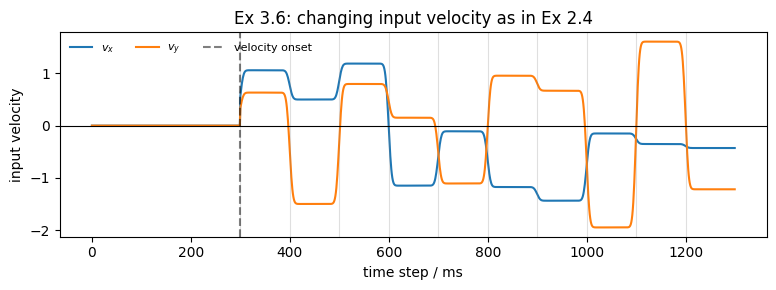

In [6]:
from pathlib import Path

FIGURES_DIR = Path.cwd().parent / "figures" if Path.cwd().name == "source_code" else Path.cwd() / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

t = np.arange(len(velocity_changing))
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t, velocity_changing[:, 0], label="$v_x$")
ax.plot(t, velocity_changing[:, 1], label="$v_y$")
for start in segment_starts:
    ax.axvline(start, color="gray", alpha=0.25, linewidth=0.8)
ax.axvline(300, color="k", linestyle="--", alpha=0.5, label="velocity onset")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("time step / ms")
ax.set_ylabel("input velocity")
ax.set_title("Ex 3.6: changing input velocity as in Ex 2.4")
ax.legend(frameon=False, ncol=3, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "ex36_velocity_trace.png", bbox_inches="tight")
plt.show()


In [7]:
def crop_center(img, crop_size=36):
    """Crop the central region to reduce boundary artifacts."""
    m = img.shape[0]
    start = (m - crop_size) // 2
    end = start + crop_size
    return img[start:end, start:end]


def _overlap_slices(length, shift):
    """Slices for comparing a[y, x] with b[y+dy, x+dx] without wrapping."""
    if shift >= 0:
        return slice(0, length - shift), slice(shift, length)
    return slice(-shift, length), slice(0, length + shift)


def normalized_overlap_score(a, b, dx, dy):
    """Normalized correlation score for a non-circular shift."""
    ay, by = _overlap_slices(a.shape[0], dy)
    ax, bx = _overlap_slices(a.shape[1], dx)
    patch_a = a[ay, ax]
    patch_b = b[by, bx]

    patch_a = patch_a - patch_a.mean()
    patch_b = patch_b - patch_b.mean()
    denom = np.linalg.norm(patch_a) * np.linalg.norm(patch_b)
    if denom < 1e-12:
        return -np.inf
    return np.sum(patch_a * patch_b) / denom


def estimate_shift_by_direct_search(img1, img2, max_shift=8, crop_size=36):
    """
    Estimate how much img2 is shifted relative to img1.
    This search is non-periodic: shifted images are compared only on their
    overlapping region, so activity is not wrapped across the boundary.
    """
    a = crop_center(img1, crop_size=crop_size)
    b = crop_center(img2, crop_size=crop_size)

    best_score = -np.inf
    best_dx, best_dy = 0, 0
    for dy in range(-max_shift, max_shift + 1):
        for dx in range(-max_shift, max_shift + 1):
            score = normalized_overlap_score(a, b, dx=dx, dy=dy)
            if score > best_score:
                best_score = score
                best_dx, best_dy = dx, dy
    return best_dx, best_dy


def estimate_segment_velocities_aperiodic(
    activity,
    segment_starts,
    segment_steps=100,
    dt_ms=1.0,
    window=10,
    max_shift=8,
    crop_size=36,
):
    """Estimate one drift velocity per segment from early and late frames."""
    estimated = []
    for start in segment_starts:
        start = int(start)
        end = int(start + segment_steps)
        frame_a = activity[start:start + window].mean(axis=0)
        frame_b = activity[end - window:end].mean(axis=0)
        dx, dy = estimate_shift_by_direct_search(
            frame_a,
            frame_b,
            max_shift=max_shift,
            crop_size=crop_size,
        )
        duration_ms = (segment_steps - window) * dt_ms
        estimated.append((dx / duration_ms, dy / duration_ms))
    return np.array(estimated)


def rescale_to_match(true, estimated):
    """Best scalar rescaling for comparing temporal trends."""
    denom = np.sum(estimated**2)
    if denom < 1e-12:
        return estimated, 1.0
    scale = np.sum(true * estimated) / denom
    return estimated * scale, scale


In [8]:
estimated_velocities = estimate_segment_velocities_aperiodic(
    rate_total,
    segment_starts=segment_starts,
    segment_steps=100,
    dt_ms=params3.dt_ms,
    window=10,
    max_shift=8,
    crop_size=36,
)

true_segment_velocities = []
for start in segment_starts:
    start = int(start)
    end = int(start + 100)
    true_segment_velocities.append(velocity_changing[start:end].mean(axis=0))
true_segment_velocities = np.array(true_segment_velocities)

estimated_scaled = np.zeros_like(estimated_velocities)
estimated_scaled[:, 0], scale_x = rescale_to_match(
    true_segment_velocities[:, 0],
    estimated_velocities[:, 0],
)
estimated_scaled[:, 1], scale_y = rescale_to_match(
    true_segment_velocities[:, 1],
    estimated_velocities[:, 1],
)

corr_x = np.corrcoef(true_segment_velocities[:, 0], estimated_scaled[:, 0])[0, 1]
corr_y = np.corrcoef(true_segment_velocities[:, 1], estimated_scaled[:, 1])[0, 1]

print("true mean segment velocities:")
print(true_segment_velocities)
print("estimated drift velocities before rescaling:")
print(estimated_velocities)
print(f"scale_x = {scale_x:.3f}, scale_y = {scale_y:.3f}")
print(f"corr_x = {corr_x:.3f}, corr_y = {corr_y:.3f}")


true mean segment velocities:
[[ 1.02973673  0.57889322]
 [ 0.52579084 -1.41261824]
 [ 1.12951322  0.74046547]
 [-1.08249592  0.14000866]
 [-0.14969743 -1.04231928]
 [-1.16007342  0.9109688 ]
 [-1.40759552  0.62358807]
 [-0.17898952 -1.8276848 ]
 [-0.34905228  1.48358765]
 [-0.42705646 -1.16334978]]
estimated drift velocities before rescaling:
[[ 0.01111111  0.01111111]
 [ 0.01111111 -0.02222222]
 [ 0.02222222  0.01111111]
 [-0.02222222  0.        ]
 [ 0.         -0.02222222]
 [-0.02222222  0.01111111]
 [-0.02222222  0.01111111]
 [ 0.         -0.03333333]
 [ 0.          0.02222222]
 [-0.01111111 -0.01111111]]
scale_x = 54.672, scale_y = 60.152
corr_x = 0.967, corr_y = 0.980


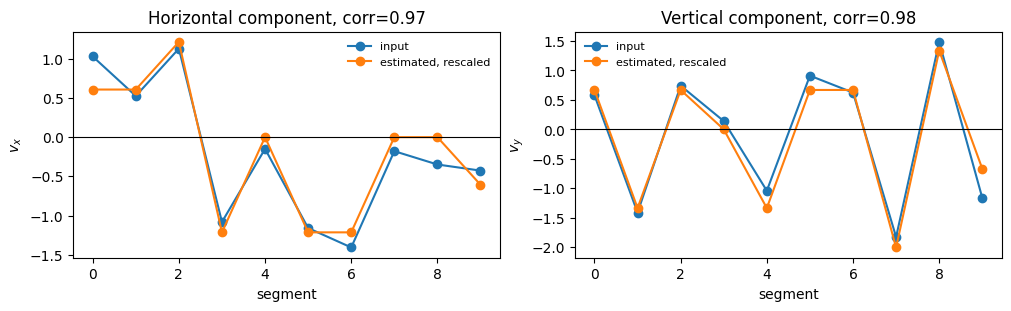

In [9]:
segments = np.arange(len(segment_starts))
fig, axes = plt.subplots(1, 2, figsize=(10, 3), constrained_layout=True)

axes[0].plot(segments, true_segment_velocities[:, 0], "o-", label="input")
axes[0].plot(segments, estimated_scaled[:, 0], "o-", label="estimated, rescaled")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("segment")
axes[0].set_ylabel("$v_x$")
axes[0].set_title(f"Horizontal component, corr={corr_x:.2f}")
axes[0].legend(frameon=False, fontsize=8)

axes[1].plot(segments, true_segment_velocities[:, 1], "o-", label="input")
axes[1].plot(segments, estimated_scaled[:, 1], "o-", label="estimated, rescaled")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("segment")
axes[1].set_ylabel("$v_y$")
axes[1].set_title(f"Vertical component, corr={corr_y:.2f}")
axes[1].legend(frameon=False, fontsize=8)

fig.savefig(FIGURES_DIR / "ex36_velocity_scatter.png", bbox_inches="tight")
plt.show()


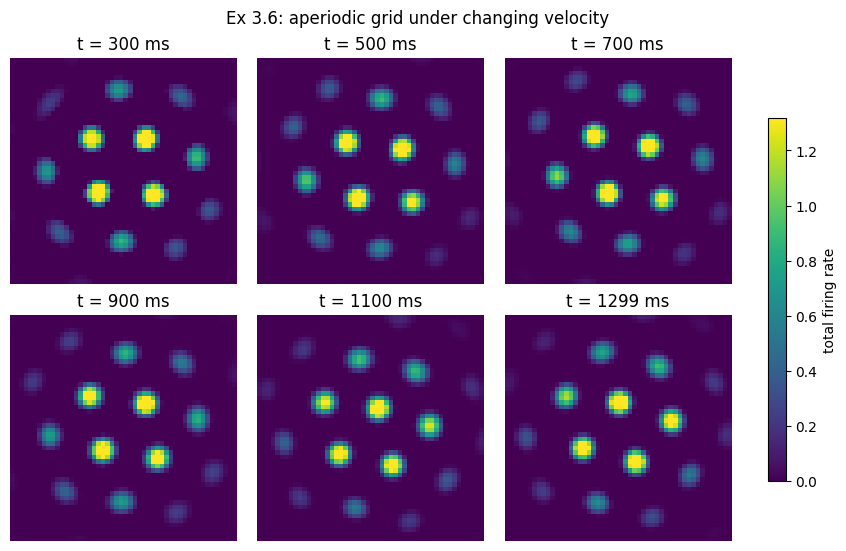

In [10]:
time_points = [300, 500, 700, 900, 1100, len(rate_total) - 1]
fig, axes = plt.subplots(2, 3, figsize=(8.5, 5.4), constrained_layout=True)
vmax = np.percentile(rate_total, 99)

for ax, tp in zip(axes.ravel(), time_points):
    im = ax.imshow(rate_total[tp], origin="lower", cmap="viridis", vmin=0, vmax=vmax)
    ax.set_title(f"t = {tp} ms")
    ax.axis("off")

fig.colorbar(im, ax=axes, shrink=0.75, label="total firing rate")
fig.suptitle("Ex 3.6: aperiodic grid under changing velocity")
fig.savefig(FIGURES_DIR / "ex36_snapshots.png", bbox_inches="tight")
plt.show()


For this bonus simulation, I used the input-envelope aperiodic model from Ex. 3.4 and generated the velocity input as in Ex. 2.4. After a zero-velocity warm-up, the velocity direction changed every 100 ms and the speed was sampled uniformly from $[1,2]$, with a small smoothing at transitions.

To estimate the drift of the grid pattern, I did not use circular FFT phase correlation, because the aperiodic network does not wrap around at the boundaries. Instead, I cropped the central region of the activity maps and searched over small non-circular shifts $(dx,dy)$. For each candidate shift, I compared only the overlapping pixels and chose the shift with the largest normalized correlation. This gives one estimated grid displacement per segment.

The estimated grid velocity follows the input velocity qualitatively after rescaling. The match is not perfect, especially because the aperiodic boundary and the input envelope make the grid pattern change shape and amplitude while it moves. Thus the pattern does not behave as a perfectly rigid translation, but the sign and broad temporal trend of the drift are still visible.